In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from tqdm import tqdm

In [4]:
TRAIN_DIR = "/content/drive/MyDrive/datasets/train"
TEST_DIR = "/content/drive/MyDrive/datasets/test"
IMAGE_SIZE = (128, 128)

In [5]:
X, y = [], []
print("📦 Loading training dataset...")
for label in tqdm(os.listdir(TRAIN_DIR)):
    label_path = os.path.join(TRAIN_DIR, label)
    if not os.path.isdir(label_path):
        continue
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        try:
            img = load_img(img_path, target_size=IMAGE_SIZE)
            img_array = img_to_array(img)
            X.append(img_array)
            y.append(label)
        except:
            pass

📦 Loading training dataset...


100%|██████████| 21/21 [11:32<00:00, 32.98s/it]


In [6]:
X = np.array(X, dtype="float32") / 255.0
y = np.array(y)
print(f"✅ Loaded {len(X)} images from {len(np.unique(y))} classes.")

✅ Loaded 6399 images from 21 classes.


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_val_flat = scaler.transform(X_val_flat)


In [8]:
print("\n Training Complex Decision Tree...")
complex_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,         # grow tree fully
    min_samples_split=2,    # allow splits down to single samples
    random_state=42
)
complex_tree.fit(X_train_flat, y_train_enc)


 Training Complex Decision Tree...


DecisionTreeClassifier(random_state=42)

In [9]:
y_pred_val = complex_tree.predict(X_val_flat)
print("\n Validation Results:")
print("Accuracy:", accuracy_score(y_val_enc, y_pred_val))
print("\nClassification Report:")
print(classification_report(y_val_enc, y_pred_val, target_names=label_encoder.classes_))


 Validation Results:
Accuracy: 0.634375

Classification Report:
                                           precision    recall  f1-score   support

                     Grape__black_measles       0.73      0.72      0.72       198
                         Grape__black_rot       0.55      0.58      0.56       142
                           Grape__healthy       0.34      0.37      0.35        68
Grape__leaf_blight_(isariopsis_leaf_spot)       0.66      0.60      0.63       128
                          Lemon__diseased       0.31      0.40      0.35        10
                           Lemon__healthy       0.77      0.77      0.77        22
                    Pomegranate__diseased       0.76      0.84      0.80        38
                     Pomegranate__healthy       0.79      0.78      0.78        40
                       guava_Disease Free       0.44      0.44      0.44        18
                        guava_Phytopthora       0.22      0.12      0.16        16
                     

In [10]:
X_test, y_test = [], []
print("\n Loading test dataset...")
for label in tqdm(os.listdir(TEST_DIR)):
    label_path = os.path.join(TEST_DIR, label)
    if not os.path.isdir(label_path):
        continue
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        try:
            img = load_img(img_path, target_size=IMAGE_SIZE)
            img_array = img_to_array(img)
            X_test.append(img_array)
            y_test.append(label)
        except:
            pass

X_test = np.array(X_test, dtype="float32") / 255.0
y_test = np.array(y_test)

X_test_flat = X_test.reshape(len(X_test), -1)
X_test_flat = scaler.transform(X_test_flat)
y_test_enc = label_encoder.transform(y_test)


 Loading test dataset...


100%|██████████| 21/21 [06:08<00:00, 17.56s/it]


In [11]:
y_pred_test = complex_tree.predict(X_test_flat)
acc = accuracy_score(y_test_enc, y_pred_test)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, y_pred_test, average='weighted')

print("\n🎯 Test Results (Complex Decision Tree):")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_test, target_names=label_encoder.classes_))


🎯 Test Results (Complex Decision Tree):
Accuracy: 0.6100
Precision: 0.6113
Recall: 0.6100
F1 Score: 0.6085

Classification Report:
                                           precision    recall  f1-score   support

                     Grape__black_measles       0.68      0.63      0.66       277
                         Grape__black_rot       0.58      0.56      0.57       200
                           Grape__healthy       0.43      0.43      0.43        94
Grape__leaf_blight_(isariopsis_leaf_spot)       0.63      0.66      0.64       178
                          Lemon__diseased       0.37      0.62      0.47        16
                           Lemon__healthy       0.74      0.53      0.62        32
                    Pomegranate__diseased       0.85      0.85      0.85        55
                     Pomegranate__healthy       0.80      0.88      0.84        58
                       guava_Disease Free       0.43      0.35      0.38        26
                        guava_Phytopt

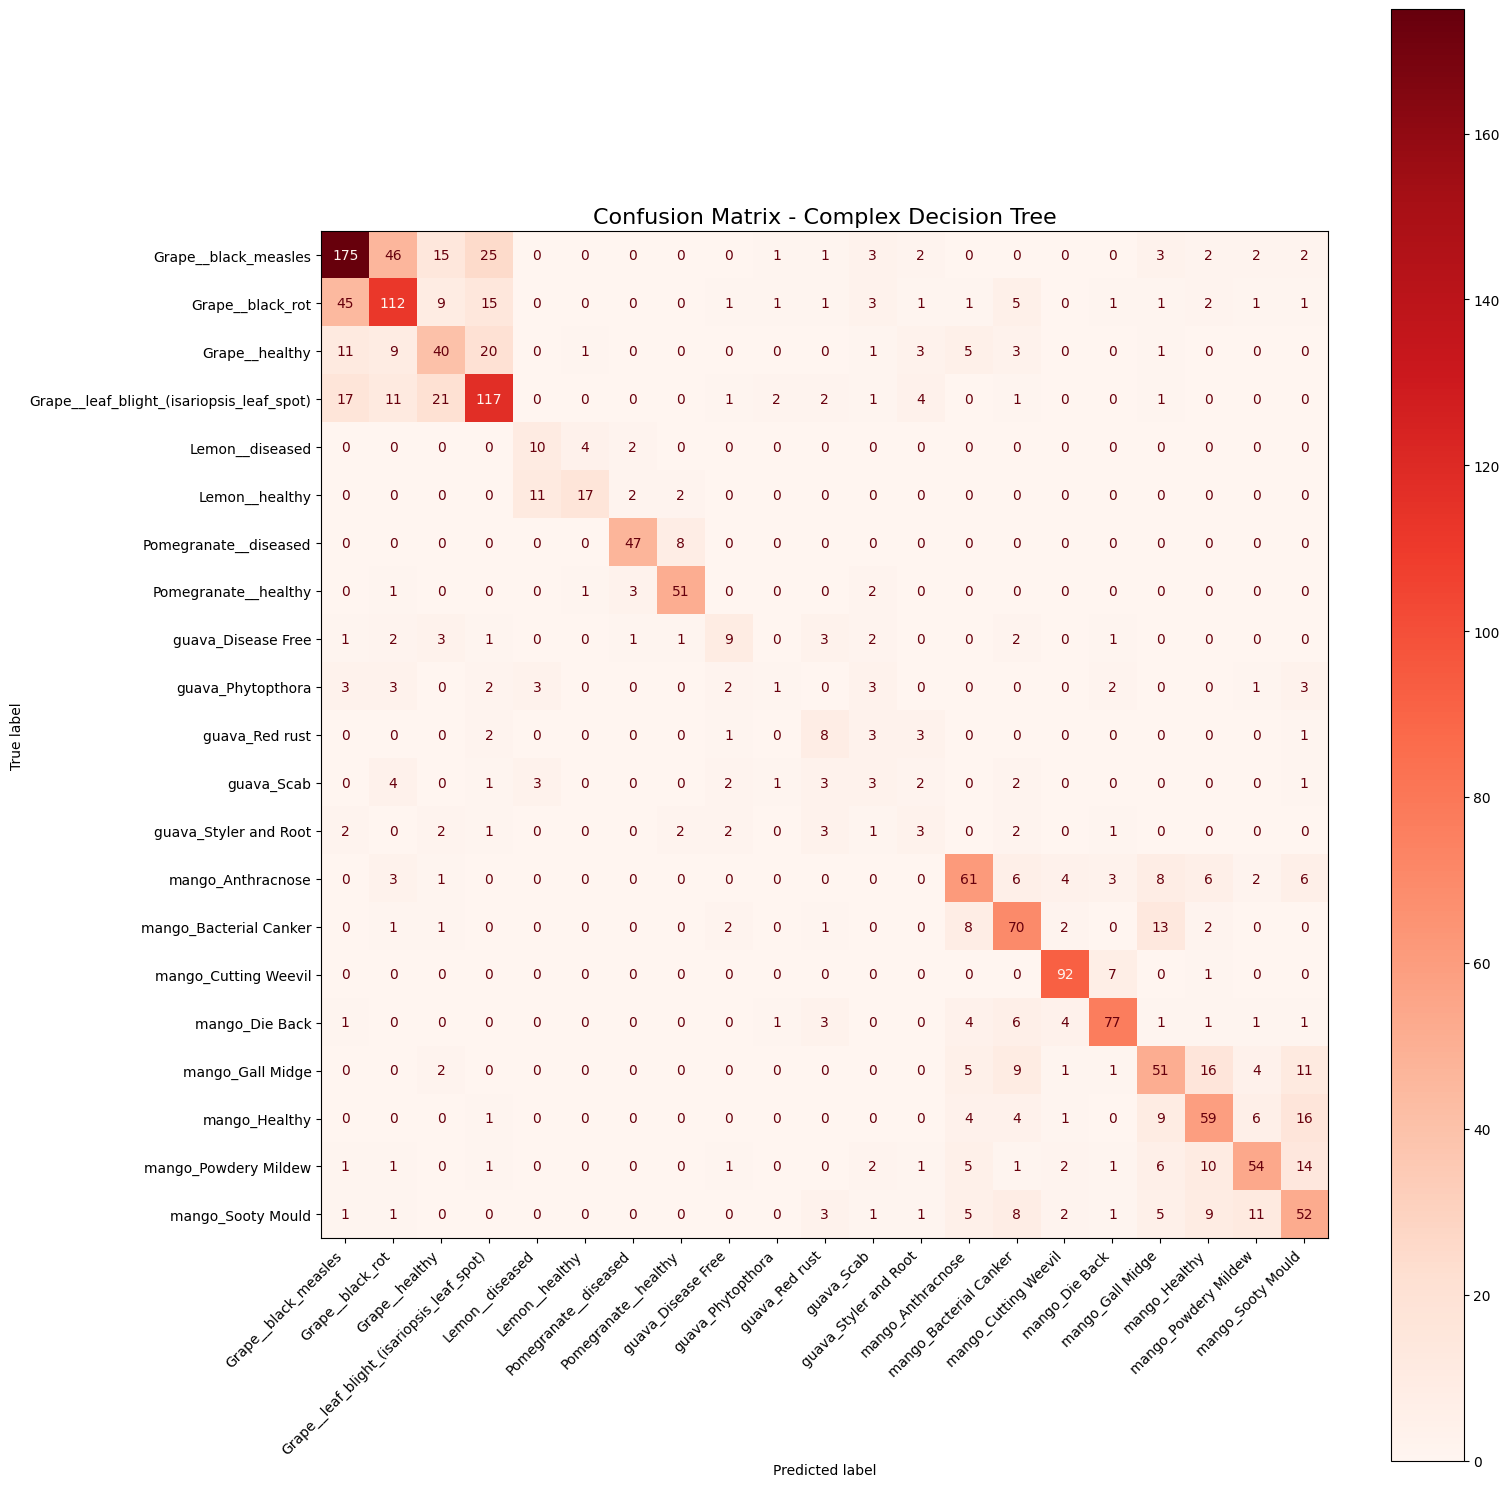

In [18]:
fig, ax = plt.subplots(figsize=(16, 16))  # Make it larger
disp.plot(cmap="Reds", ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Complex Decision Tree", fontsize=16)
plt.xticks(fontsize=10, rotation=45, ha='right')  # Rotate & align labels
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

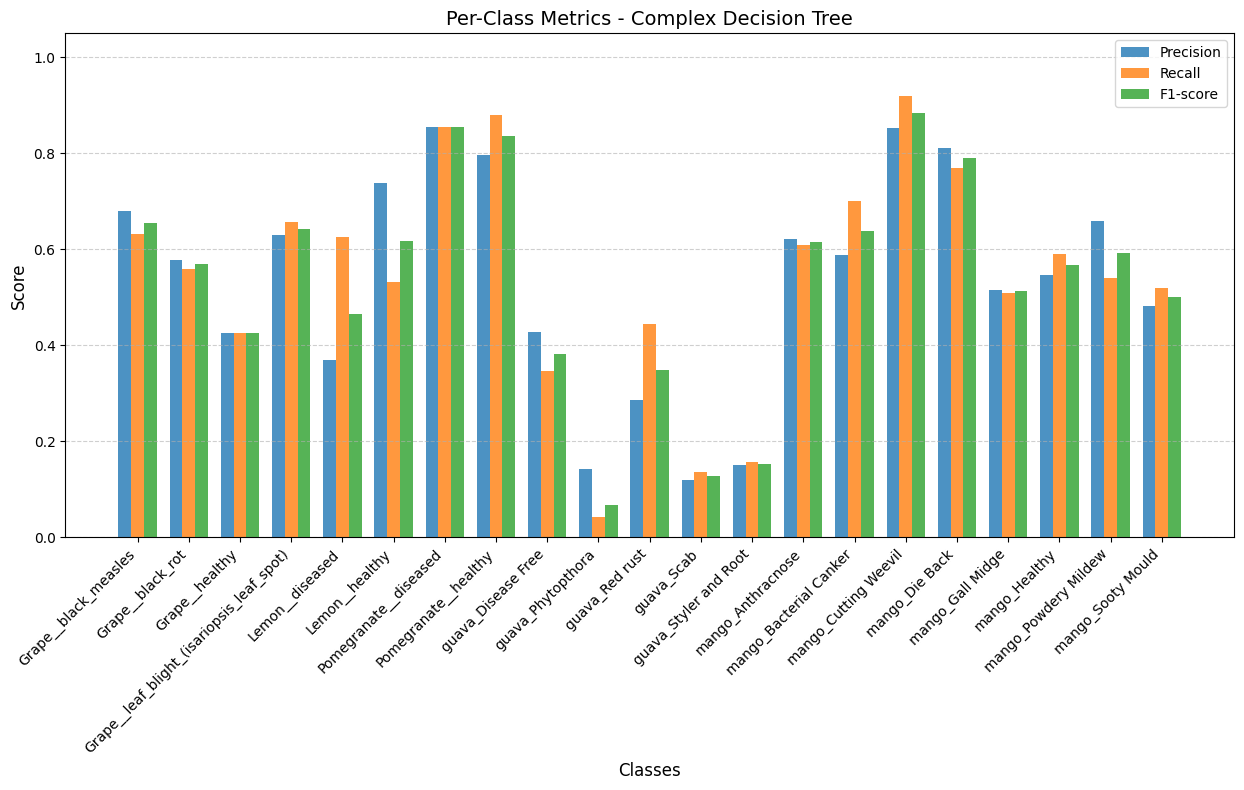

In [19]:
plt.figure(figsize=(max(10, len(label_encoder.classes_) * 0.6), 8))  # auto-scale width
x = np.arange(len(label_encoder.classes_))
bar_width = 0.25

plt.bar(x - bar_width, precisions, width=bar_width, label='Precision', alpha=0.8)
plt.bar(x, recalls, width=bar_width, label='Recall', alpha=0.8)
plt.bar(x + bar_width, f1s, width=bar_width, label='F1-score', alpha=0.8)

plt.xticks(x, label_encoder.classes_, rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Per-Class Metrics - Complex Decision Tree", fontsize=14)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()